In [28]:
import pandas as pd
import matplotlib.pyplot as plt

arquivo = "data_RS.xlsx"

jaguarao = pd.read_excel(arquivo, sheet_name="(URF) 1010252 - JAGUARAO")

bage = pd.read_excel(arquivo, sheet_name="(URF) 1010253 - BAGE")

santana_do_livramento = pd.read_excel(arquivo, sheet_name="(URF) 1010351 - IRF SANTANA DO ")

uruguaiana = pd.read_excel(arquivo, sheet_name="(URF) 1010900 - URUGUAIANA")

sao_borja = pd.read_excel(arquivo, sheet_name="(URF) 1010953 - SAO BORJA")

chui = pd.read_excel(arquivo, sheet_name="(URF) 1015500 - CHUI")

santana_do_livramento2 = pd.read_excel(arquivo, sheet_name="(URF) 1015600 - SANTANA DO LIVR")

uruguaiana2 = pd.read_excel(arquivo, sheet_name="(URF) 1017500 - ALF - URUGUAIAN")

sao_borja2 = pd.read_excel(arquivo, sheet_name="(URF) 1017503 - IRF - SÃO BORJA")

aeroporto_salgado = pd.read_excel(arquivo, sheet_name="(URF) 1017600 - AEROPORTO SALGA")

chui2 = pd.read_excel(arquivo, sheet_name="(URF) 1017701 - IRF - CHUÍ")

rio_grande = pd.read_excel(arquivo, sheet_name="(URF) 1017700 - PORTO DE RIO GR")

porto_alegre = pd.read_excel(arquivo, sheet_name="(URF) 1017800 - ALF - PORTO ALE")

aeroporto_salgado2 = pd.read_excel(arquivo, sheet_name="(URF) 1017801 - IRF - AEROPORTO")

santana_do_livramento3 = pd.read_excel(arquivo, sheet_name="(URF) 1017900 - ALF - SANTANA D")

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import re

arquivo = "data_RS.xlsx"
abas = pd.read_excel(arquivo, sheet_name=None)

nomes_portos = {
    "1010252": "1010252 - Jaguarão",
    "1010253": "1010253 - Bagé",
    "1010351": "1010351 - IRF Santana do Livramento",
    "1010900": "1010900 - Uruguaiana",
    "1010953": "1010953 - São Borja",
    "1015500": "1015500 - Chuí",
    "1015600": "1015600 - Santana do Livramento",
    "1017500": "1017500 - ALF Uruguaiana",
    "1017503": "1017503 - IRF São Borja",
    "1017600": "1017600 - Aeroporto Salgado Filho",
    "1017700": "1017700 - Porto de Rio Grande",
    "1017701": "1017701 - IRF Chuí",
    "1017800": "1017800 - ALF Porto Alegre",
    "1017801": "1017801 - IRF Aeroporto Salgado Filho",
    "1017900": "1017900 - ALF Santana do Livramento"
}

lista_dfs = []

for nome_aba, df in abas.items():
    df = df.copy()

    codigo_match = re.search(r"\d{7}", nome_aba)
    if codigo_match:
        codigo = codigo_match.group()
        df["Porto_URF"] = nomes_portos.get(codigo, f"{codigo} - Nome não mapeado")
        lista_dfs.append(df)

base = pd.concat(lista_dfs, ignore_index=True)

base["Peso_KG"] = pd.to_numeric(base["Peso_KG"], errors="coerce")
base["Ano"] = pd.to_numeric(base["Ano"], errors="coerce")

base = base.dropna(subset=["Porto_URF", "Ano", "Peso_KG"])
base["Ano"] = base["Ano"].astype(int)

In [30]:
df_porto_ano = (
    base.groupby(["Porto_URF", "Ano"], as_index=False)["Peso_KG"]
    .sum()
)

df_porto_ano["Peso_milhoes"] = df_porto_ano["Peso_KG"] / 1_000_000

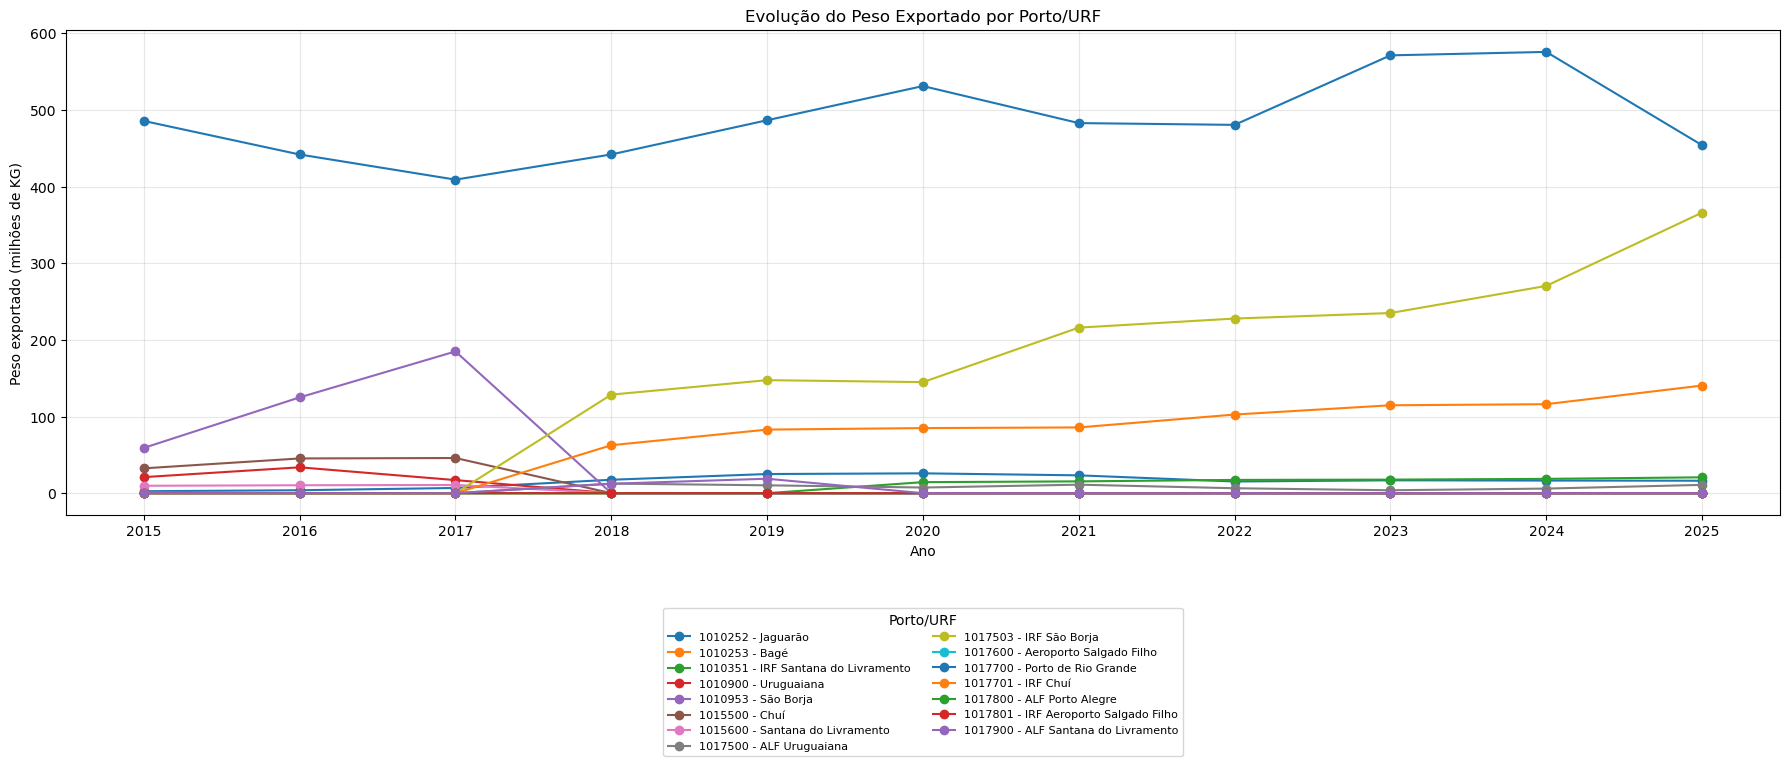

In [31]:
grafico = df_porto_ano.copy()

tabela_grafico = grafico.pivot(
    index="Ano",
    columns="Porto_URF",
    values="Peso_milhoes"
).fillna(0)

plt.figure(figsize=(18, 8))

for porto in tabela_grafico.columns:
    plt.plot(
        tabela_grafico.index,
        tabela_grafico[porto],
        marker="o",
        label=porto
    )

plt.title("Evolução do Peso Exportado por Porto/URF")
plt.xlabel("Ano")
plt.ylabel("Peso exportado (milhões de KG)")
plt.xticks(tabela_grafico.index)

plt.legend(
    title="Porto/URF",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=2,
    fontsize=8
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

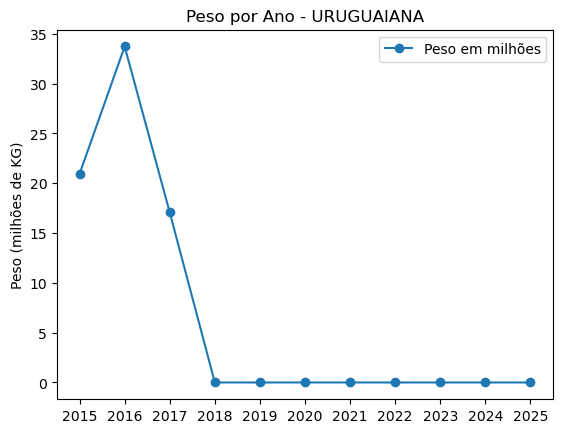

In [32]:
df_ano = (
    uruguaiana
    .groupby("Ano")["Peso_KG"]
    .sum()
    .reset_index()
)

df_ano["Peso_milhoes"] = df_ano["Peso_KG"] / 1_000_000

plt.figure()
plt.plot(df_ano["Ano"], df_ano["Peso_milhoes"], marker='o', label="Peso em milhões")
plt.title("Peso por Ano - URUGUAIANA")
plt.xticks(range(df_ano["Ano"].min(), df_ano["Ano"].max() + 1))
plt.ylabel("Peso (milhões de KG)")
plt.legend()
plt.show()

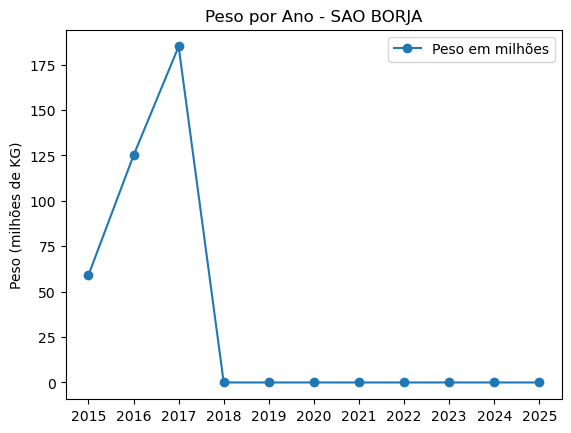

In [33]:
df_ano = (
    sao_borja
    .groupby("Ano")["Peso_KG"]
    .sum()
    .reset_index()
)

df_ano["Peso_milhoes"] = df_ano["Peso_KG"] / 1_000_000

plt.figure()
plt.plot(df_ano["Ano"], df_ano["Peso_milhoes"], marker='o', label="Peso em milhões")
plt.title("Peso por Ano - SAO BORJA")
plt.xticks(range(df_ano["Ano"].min(), df_ano["Ano"].max() + 1))
plt.ylabel("Peso (milhões de KG)")
plt.legend()
plt.show()

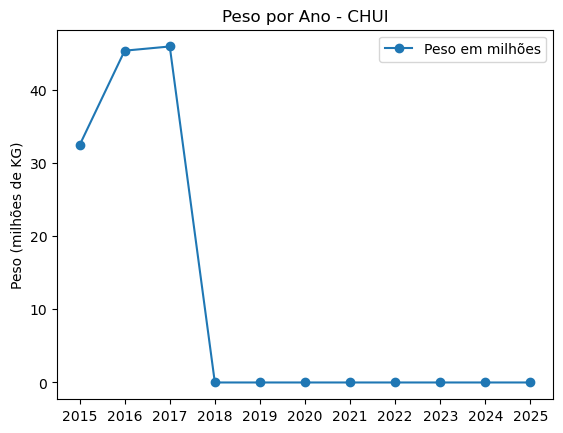

In [34]:
df_ano = (
    chui
    .groupby("Ano")["Peso_KG"]
    .sum()
    .reset_index()
)

df_ano["Peso_milhoes"] = df_ano["Peso_KG"] / 1_000_000

plt.figure()
plt.plot(df_ano["Ano"], df_ano["Peso_milhoes"], marker='o', label="Peso em milhões")
plt.title("Peso por Ano - CHUI")
plt.xticks(range(df_ano["Ano"].min(), df_ano["Ano"].max() + 1))
plt.ylabel("Peso (milhões de KG)")
plt.legend()
plt.show()

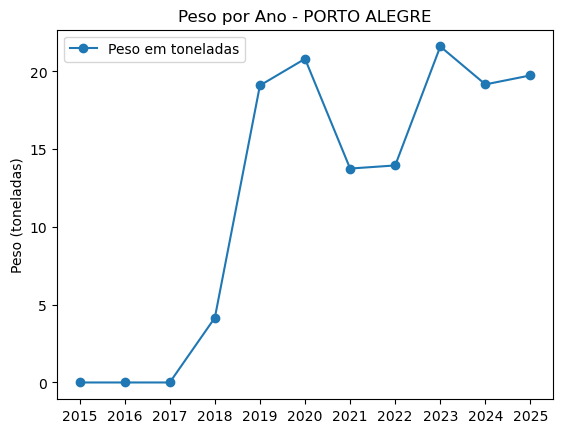

In [35]:
df_ano = (
    porto_alegre
    .groupby("Ano")["Peso_KG"]
    .sum()
    .reset_index()
)

df_ano["Peso_milhoes"] = df_ano["Peso_KG"] / 1_000

plt.figure()
plt.plot(df_ano["Ano"], df_ano["Peso_milhoes"], marker='o', label="Peso em toneladas")
plt.title("Peso por Ano - PORTO ALEGRE")
plt.xticks(range(df_ano["Ano"].min(), df_ano["Ano"].max() + 1))
plt.ylabel("Peso (toneladas)")
plt.legend()
plt.show()

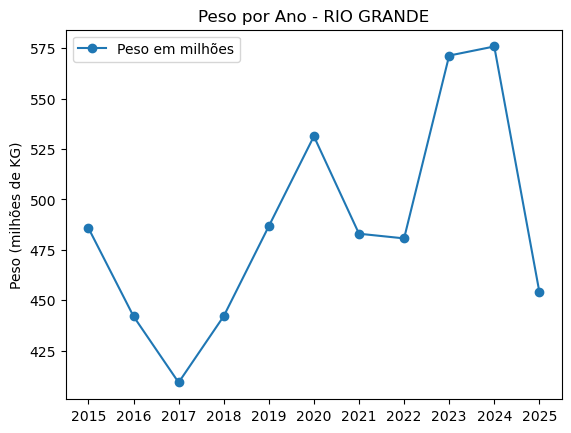

In [36]:
df_ano = (
    rio_grande
    .groupby("Ano")["Peso_KG"]
    .sum()
    .reset_index()
)

df_ano["Peso_milhoes"] = df_ano["Peso_KG"] / 1_000_000

plt.figure()
plt.plot(df_ano["Ano"], df_ano["Peso_milhoes"], marker='o', label="Peso em milhões")
plt.title("Peso por Ano - RIO GRANDE")
plt.xticks(range(df_ano["Ano"].min(), df_ano["Ano"].max() + 1))
plt.ylabel("Peso (milhões de KG)")
plt.legend()
plt.show()

In [37]:
import pandas as pd

arquivo = "data_RS.xlsx"

abas = [
    "JAGUARAO",
    "BAGE",
    "SANTANA DO LIVRAMENTO ",
    "URUGUAIANA",
    "SAO BORJA",
    "CHUI",
    "PORTO ALEGRE",
    "RIO GRANDE"
]

lista_df = []

for aba in abas:
    df = pd.read_excel(arquivo, sheet_name=aba)
    lista_df.append(df)

# juntar tudo
df_total = pd.concat(lista_df, ignore_index=True)

# agrupar por ano (somando tudo)
df_ano_total = (
    df_total
    .groupby("Ano")["Peso_KG"]
    .sum()
    .reset_index()
)

print(df_ano_total)

ValueError: Worksheet named 'JAGUARAO' not found

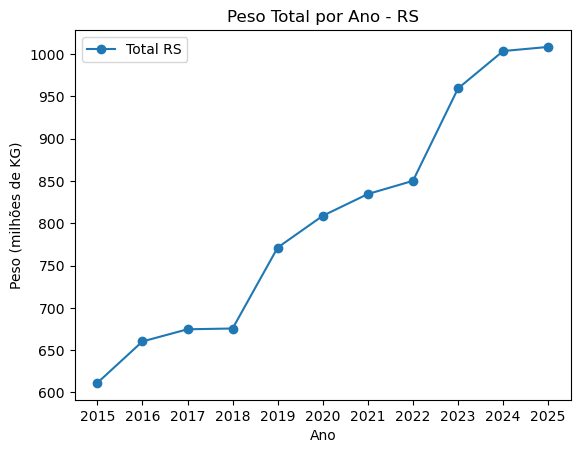

In [ ]:
import matplotlib.pyplot as plt

df_ano_total["Peso_milhoes"] = df_ano_total["Peso_KG"] / 1_000_000

plt.figure()
plt.plot(df_ano_total["Ano"], df_ano_total["Peso_milhoes"], marker='o', label="Total RS")

plt.title("Peso Total por Ano - RS")
plt.xlabel("Ano")
plt.ylabel("Peso (milhões de KG)")
plt.xticks(range(df_ano_total["Ano"].min(), df_ano_total["Ano"].max() + 1))

plt.legend()
plt.show()

In [ ]:
import pandas as pd

arquivo = "data_RS.xlsx"

abas = [
    "JAGUARAO",
    "BAGE",
    "SANTANA DO LIVRAMENTO ",
    "URUGUAIANA",
    "SAO BORJA",
    "CHUI",
    "PORTO ALEGRE",
    "RIO GRANDE"
]

lista_df = []

for aba in abas:
    df = pd.read_excel(arquivo, sheet_name=aba)
    lista_df.append(df)

# juntar tudo
df_total = pd.concat(lista_df, ignore_index=True)

# agrupar por ano (somando tudo)
df_media_total = (
    df_total
    .groupby("Ano")["Peso_KG"]
    .mean()
    .reset_index()
)


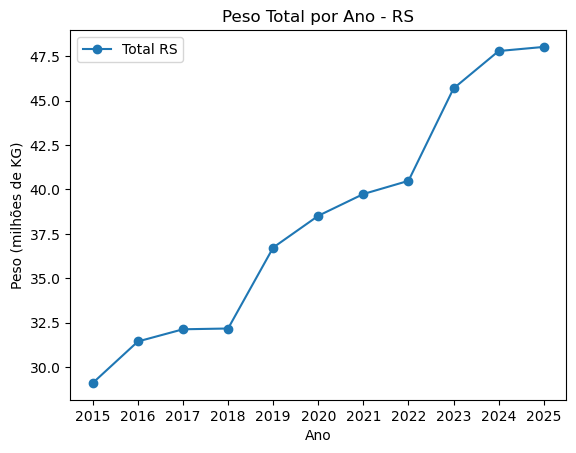

In [ ]:
df_media_total["Peso_milhoes"] = df_media_total["Peso_KG"] / 1_000_000

plt.figure()
plt.plot(df_media_total["Ano"], df_media_total["Peso_milhoes"], marker='o', label="Total RS")

plt.title("Peso Total por Ano - RS")
plt.xlabel("Ano")
plt.ylabel("Peso (milhões de KG)")
plt.xticks(range(df_media_total["Ano"].min(), df_media_total["Ano"].max() + 1))

plt.legend()
plt.show()

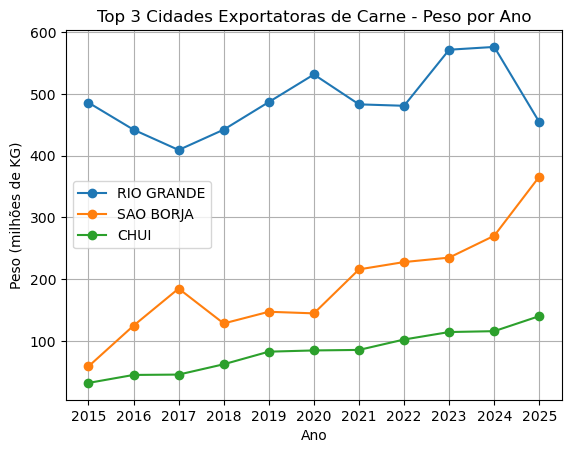

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

arquivo = "data_RS.xlsx"

abas = [
    "JAGUARAO",
    "BAGE",
    "SANTANA DO LIVRAMENTO ",
    "URUGUAIANA",
    "SAO BORJA",
    "CHUI",
    "PORTO ALEGRE",
    "RIO GRANDE"
]

# juntar todas as abas
lista_df = []
for aba in abas:
    df = pd.read_excel(arquivo, sheet_name=aba)
    df["URF"] = aba.strip()  # cria coluna identificando a origem
    lista_df.append(df)

df_total = pd.concat(lista_df, ignore_index=True)

# descobrir os 3 maiores (total geral)
top3 = (
    df_total
    .groupby("URF")["Peso_KG"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

# filtrar só os 3 maiores
df_top3 = df_total[df_total["URF"].isin(top3)]

# agrupar por Ano e URF
df_ano_top3 = (
    df_top3
    .groupby(["Ano", "URF"])["Peso_KG"]
    .sum()
    .reset_index()
)

# converter para milhões
df_ano_top3["Peso_milhoes"] = df_ano_top3["Peso_KG"] / 1_000_000

# plot
plt.figure()

for urf in top3:
    dados = df_ano_top3[df_ano_top3["URF"] == urf]
    plt.plot(dados["Ano"], dados["Peso_milhoes"], marker='o', label=urf)

plt.title("Top 3 Cidades Exportatoras de Carne - Peso por Ano")
plt.xlabel("Ano")
plt.ylabel("Peso (milhões de KG)")
plt.xticks(range(df_ano_top3["Ano"].min(), df_ano_top3["Ano"].max() + 1))
plt.legend()
plt.grid()

plt.show()